# Step 2 — Feature Engineering & Baseline Models

Starting from the cleaned dataset produced in notebook 01, we derive 9 features (room type encoding, neighbourhood frequency, amenity count, etc.) and train three baseline regression models to identify the best candidate for tuning.

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [13]:
df = pd.read_csv('../data/listings_cleaned.csv')

In [14]:

df['host_verified'] = df['host_identity_verified'].map({'t': 1, 'f': 0}).fillna(0)

df['num_amenities'] = df['amenities'].str.count(',') + 1

df['price_per_person'] = df['price_clean'] / df['accommodates']

df['availability_ratio'] = df['availability_365'] / 365

df['is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0)

## Feature Selection & Encoding

We encode `room_type` as an integer and use frequency encoding for `neighbourhood_cleansed` to avoid high cardinality one-hot columns.

In [15]:
room_map = {'Entire home/apt': 2, 'Private room': 1, 'Shared room': 0, 'Hotel room': 3}
df['room_type_encoded'] = df['room_type'].map(room_map)

neigh_freq = df['neighbourhood_cleansed'].value_counts(normalize=True)
df['neighbourhood_freq'] = df['neighbourhood_cleansed'].map(neigh_freq)

In [16]:
feature_cols = [
    'bedrooms', 'bathrooms', 'accommodates', 'room_type_encoded',
    'neighbourhood_freq', 'num_amenities', 'availability_ratio',
    'is_superhost', 'host_verified'
]

print("Total features:", len(feature_cols))
X = df[feature_cols]
y = df['price_clean']

import joblib
joblib.dump(feature_cols, '../app/feature_columns.pkl')

Total features: 9


['../app/feature_columns.pkl']

## Train / Test Split & Model Comparison

We compare Linear Regression, Decision Tree, and Random Forest on MAE and R² to select the best architecture before hyperparameter tuning.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (3584, 9), Test size: (896, 9)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'R2': r2}
    print(f"{name}: MAE = ${mae:.2f}, R² = {r2:.3f}")

import joblib
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
joblib.dump(best_model, '../app/model.pkl')
print("Best model saved to app/model.pkl")

Linear Regression: MAE = $135.14, R² = 0.083
Decision Tree: MAE = $128.89, R² = 0.073


Random Forest: MAE = $122.43, R² = 0.185
Best model saved to app/model.pkl


=== Random Forest Evaluation ===
MAE:  $122.43
RMSE: $152.71
R²:   0.185
Explained variance: 0.187


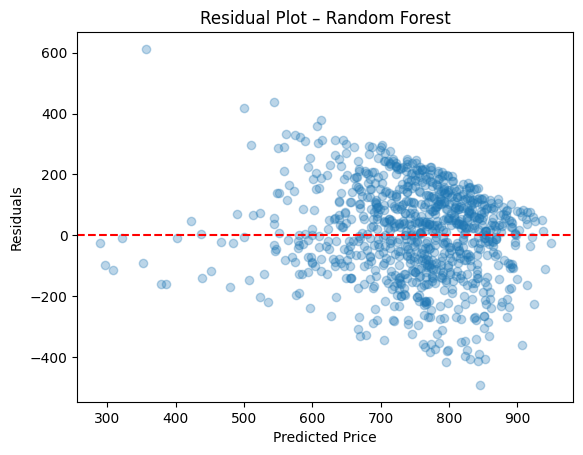

In [19]:
from sklearn.metrics import explained_variance_score, mean_squared_error
import matplotlib.pyplot as plt 
import numpy as np

y_pred_best = best_model.predict(X_test)

print("=== Random Forest Evaluation ===")
print(f"MAE:  ${mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_best):.3f}")
print(f"Explained variance: {explained_variance_score(y_test, y_pred_best):.3f}")

residuals = y_test - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot – Random Forest')
plt.show()